In [119]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import matplotlib.image as mpimg
from scipy.interpolate import CubicSpline

Start Coordinate (Red): [526 200]
End Coordinate (Green): [111 173]


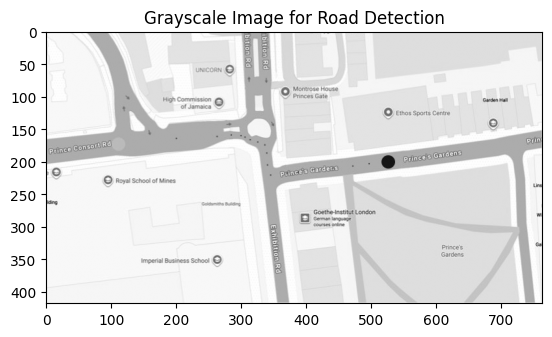

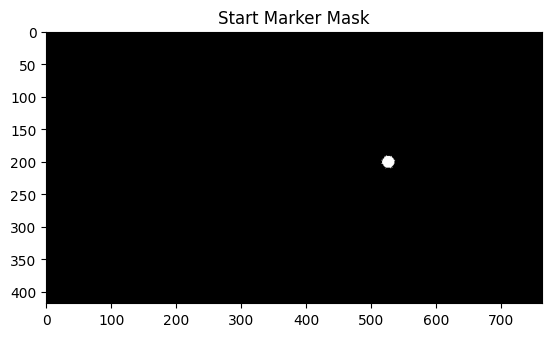

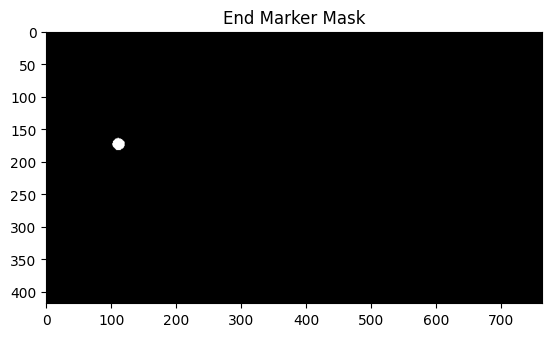

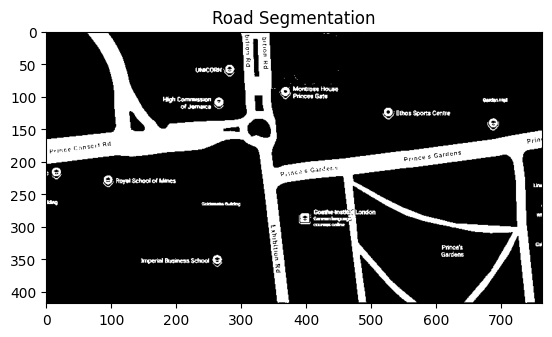

In [120]:
# 1. Load and Preprocess the Image
# The brief specifies using CW2Map.jpg [cite: 1906]
img = mpimg.imread('CW2Map.jpg') 
# Normalize to 0-1 range for easier thresholding
img = img.astype(float) / 255.0

# Extract individual channels
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]


red_mask = (R > 0.7) & (G < 0.4) & (B < 0.4)

green_mask = (G > 0.6) & (G > R * 1.5) & (G > B * 1.5)

def find_point(mask):
    """Calculates the (x, y) center of a binary mask."""
    coords = np.argwhere(mask)
    if len(coords) == 0: return None
    # y is index 0 (rows), x is index 1 (cols)
    return np.mean(coords, axis=0)[::-1].astype(int) # Return (x, y) 

start_pos = find_point(red_mask)
end_pos = find_point(green_mask)

print(f"Start Coordinate (Red): {start_pos}")
print(f"End Coordinate (Green): {end_pos}")

# 3. Identify Roads using Thresholding 
# Convert to grayscale to isolate the grey paths 
# Road is grey (~0.5 intensity), background is white (~1.0)
gray = 0.299 * R + 0.587 * G + 0.114 * B
road_mask = (gray < 0.85) & (gray > 0.1) # Exclude white background and deep black lines

# show greyscale image
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image for Road Detection')
plt.show()


def convolution(image, kernel, w):
    """
    Manually slides a kernel over an image.
    w is the width of the kernel (assumed to be square and odd)
    """
    img_h, img_w = image.shape
    
    # Create an empty output array of the same size
    output = np.zeros((img_h, img_w))
    
    # We ignore the 1-pixel border to avoid going out of bounds
    # (Padding is a more advanced option, but this is simpler)
    for y in range(1, img_h - 1):
        for x in range(1, img_w - 1):
            # Extract the 3x3 neighborhood
            region = image[y-(w//2):y+(w//2)+1, x-(w//2):x+(w//2)+1]
            # Multiply by kernel and sum
            output[y, x] = np.sum(region * kernel)
            
    return output

def find_edges(image):
    """
    Calculates edge magnitude using manual convolution.
    """
    # Kernels defined in Slide 28 of ComputerVision.pdf
    Kx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]])
    
    Ky = np.array([[-1, -2, -1], 
                   [ 0,  0,  0], 
                   [ 1,  2,  1]])
    
    gx = convolution(image, Kx, 3)
    gy = convolution(image, Ky, 3)
    
    # Magnitude of the gradient
    return np.sqrt(gx**2 + gy**2)


road_edges = find_edges(road_mask.astype(float))

# Visualization
# plt.figure(figsize=(12, 4))
# plt.subplot(131);
plt.imshow(red_mask, cmap='gray'); plt.title('Start Marker Mask')
# plt.subplot(132); 
plt.show()
plt.imshow(green_mask, cmap='gray'); plt.title('End Marker Mask')
# plt.subplot(133); 
plt.show()
plt.imshow(road_mask, cmap='gray'); plt.title('Road Segmentation')
plt.show()
# print(R.shape)

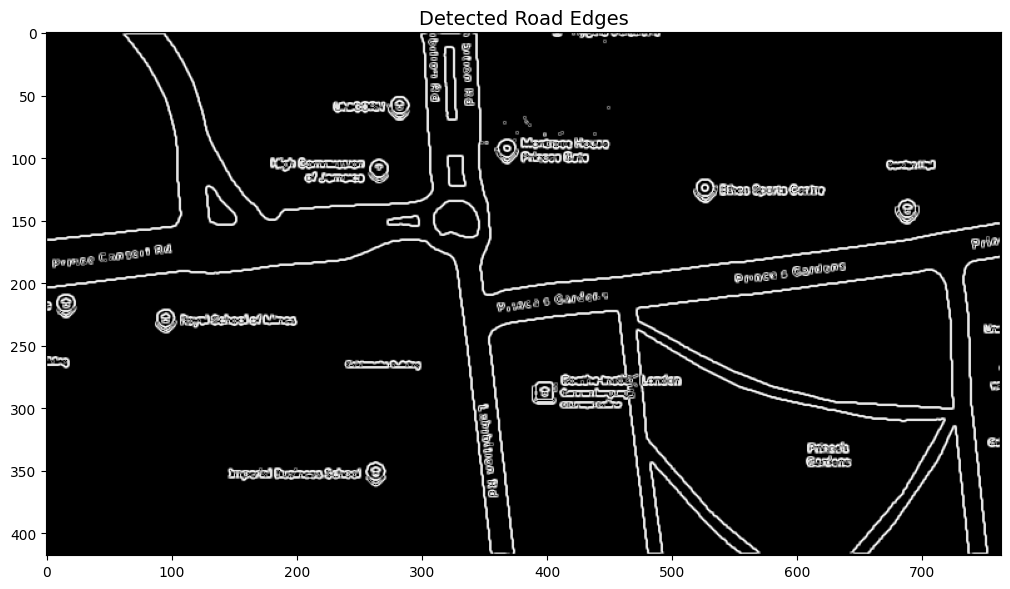

In [121]:
plt.figure(figsize=(14, 6))

# 2. Plot the detected edges
# plt.subplot(1, 2, 2)
# Using a gray colormap highlights the high-gradient areas (edges) as white
plt.imshow(road_edges, cmap='gray')
plt.title('Detected Road Edges', fontsize=14)
# plt.axis('off')

plt.tight_layout()
plt.show()

In [122]:
blue_mask = (B > 0.6) & (B > R*1.5) & (B > G*1.5)

# 3. Extract all Blue Pixel coordinates
# np.argwhere returns [row, col], so we flip to [x, y]
coords = np.argwhere(blue_mask)
path_points = coords[:, ::-1] 

# 4. Sorting the Path
# Since your path goes mostly East to West (High X to Low X), 
# we sort by X in descending order so the robot starts at the red marker side.
path_points = path_points[path_points[:, 0].argsort()[::-1]]


print(f"Extracted {len(path_points)} via points from your drawing.")

Extracted 17 via points from your drawing.


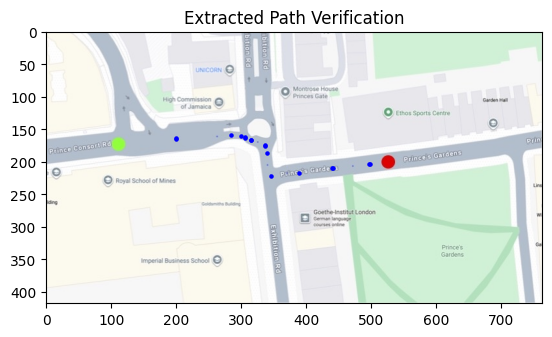

In [123]:
plt.imshow(mpimg.imread('CW2Map.jpg'))
plt.scatter(path_points[:, 0], path_points[:, 1], color='blue', s=5)
plt.title("Extracted Path Verification")
plt.show()

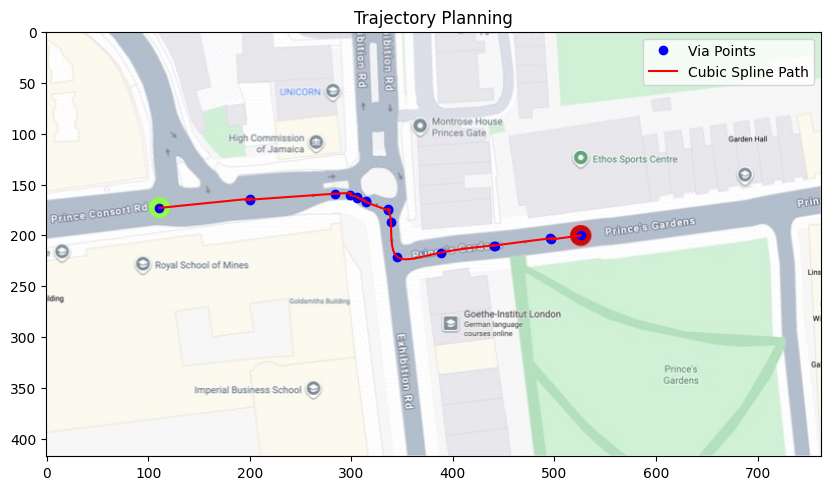

In [124]:
path_points = np.vstack((start_pos, path_points, end_pos))
# 2. Parameterize the path
# We create a 'time' array 'u' based on the number of points
u_nodes = np.linspace(0, 1, len(path_points))
u_fine = np.linspace(0, 1, 300) # 300 points for a super smooth line

# 3. Fit Cubic Splines for X and Y separately
# bc_type='natural' ensures second derivatives are zero at endpoints
cs_x = CubicSpline(u_nodes, path_points[:, 0], bc_type='natural')
cs_y = CubicSpline(u_nodes, path_points[:, 1], bc_type='natural')

# 4. Generate the smooth path
smooth_x = cs_x(u_fine)
smooth_y = cs_y(u_fine)
smooth_path = np.vstack((smooth_x, smooth_y)).T

# 5. Visualization to check against the map
img = plt.imread('CW2Map.jpg')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.plot(path_points[:, 0], path_points[:, 1], 'bo', label='Via Points')
plt.plot(smooth_path[:, 0], smooth_path[:, 1], 'r-', label='Cubic Spline Path')
plt.legend()
plt.title("Trajectory Planning")
plt.show()

In [125]:
def calculate_road_width(mask, start_coord, end_coord, axis='x'):
    """
    Calculates the average width of the road in a given range.
    axis='x' scans across columns (good for horizontal roads like Prince's Gardens).
    axis='y' scans across rows (good for vertical roads like Exhibition Road).
    """
    widths = []
    if axis == 'x':
        # For each column in range, count the longest continuous strip of road pixels
        for x in range(start_coord, end_coord):
            col = mask[:, x]
            count = 0
            max_strip = 0
            for pixel in col:
                if pixel: count += 1
                else:
                    max_strip = max(max_strip, count)
                    count = 0
            if max_strip > 5: widths.append(max_strip)
    else:
        # For each row in range, count the longest continuous strip
        for y in range(start_coord, end_coord):
            row = mask[y, :]
            count = 0
            max_strip = 0
            for pixel in row:
                if pixel: count += 1
                else:
                    max_strip = max(max_strip, count)
                    count = 0
            if max_strip > 5: widths.append(max_strip)
            
    return np.mean(widths) if widths else 0

# 1. Measure Prince's Gardens (Horizontal road on the right)
# Scan vertically across x-coordinates 500 to 650
pg_width_px = calculate_road_width(road_mask, 500, 650, axis='x')

# 2. Measure Exhibition Road (Vertical road in the middle)
# Scan horizontally across y-coordinates 250 to 350
ex_width_px = calculate_road_width(road_mask, 350, 400, axis='y')


print(f"Prince's Gardens Avg Width: {pg_width_px:.2f} px")
print(f"Exhibition Road Avg Width: {ex_width_px:.2f} px")
# print(f"Narrowest Roundabout Point: {narrow_px} px")

Prince's Gardens Avg Width: 21.95 px
Exhibition Road Avg Width: 17.46 px


In [126]:
EX_WIDTH = 7
PG_WIDTH = 9.5

scale = (EX_WIDTH / ex_width_px + PG_WIDTH / pg_width_px) / 2
print(f"Estimated Scale: {scale:.4f} meters per pixel")

Estimated Scale: 0.4169 meters per pixel


In [127]:
MIN_WIDTH = 3.85

print(f"Max Car Width: {MIN_WIDTH / 4} m") 

Max Car Width: 0.9625 m


In [128]:
CAR_WIDTH = 0.8
WHEEL_DIAMETER = 0.2

In [129]:
dt = 0.1           # Simulation time step (seconds)

# Convert your smooth_path from pixels to meters
path_meters = smooth_path * scale

# Initialize state [x, y, theta]
# Start at the first point. Assume initial heading faces the second point.
x_current, y_current = path_meters[0]
theta_current = np.arctan2(path_meters[1][1] - path_meters[0][1], 
                           path_meters[1][0] - path_meters[0][0])

robot_trajectory = [[x_current, y_current, theta_current]]  # To record the path for plotting

# Constant speeds for the open-loop movements
V_SPEED = 0.5      # meters/second
OMEGA_SPEED = 0.5  # radians/second

# 2. The Locomotion Loop
# Iterate through each point in your smoothed path
for i in range(1, len(path_meters)):
    target_x, target_y = path_meters[i]
    
    # --- STEP A: PURE ROTATION ---
    # Calculate the angle to the next target
    target_theta = np.arctan2(target_y - y_current, target_x - x_current)
    
    # Calculate the difference (normalized to -pi to pi)
    angle_diff = (target_theta - theta_current + np.pi) % (2 * np.pi) - np.pi
    
    # Determine direction to turn (1 for counter-clockwise, -1 for clockwise)
    turn_dir = 1 if angle_diff > 0 else -1
    
    # Turn until the angle difference is close to zero
    while abs(angle_diff) > 0.05:
        # 1. Set pure rotation
        v = 0.0
        omega = turn_dir * OMEGA_SPEED
        
        # 2. Inverse Kinematics (calculate required wheel speeds)
        phi_dot_R = (1/WHEEL_DIAMETER) * (v + (omega * CAR_WIDTH / 2))
        phi_dot_L = (1/WHEEL_DIAMETER) * (v - (omega * CAR_WIDTH / 2))
        
        # 3. Forward Kinematics (update robot state)
        theta_current += omega * dt
        angle_diff = (target_theta - theta_current + np.pi) % (2 * np.pi) - np.pi
    
    
    # --- STEP B: PURE TRANSLATION ---
    # Calculate distance to the target
    distance = np.sqrt((target_x - x_current)**2 + (target_y - y_current)**2)
    
    # Drive straight until the distance is covered
    while distance > 0.05:
        # 1. Set pure translation
        v = V_SPEED
        omega = 0.0
        
        # 2. Inverse Kinematics
        phi_dot_R = (1/WHEEL_DIAMETER) * (v + (omega * CAR_WIDTH / 2))
        phi_dot_L = (1/WHEEL_DIAMETER) * (v - (omega * CAR_WIDTH / 2))
        
        # 3. Forward Kinematics (update robot state)
        x_current += v * np.cos(theta_current) * dt
        y_current += v * np.sin(theta_current) * dt
        
        # Recalculate remaining distance
        distance -= v * dt 
        
        # Record the position
        robot_trajectory.append([x_current, y_current, theta_current])

# Convert the recorded trajectory back to pixels for plotting
robot_trajectory = np.array(robot_trajectory)
robot_trajectory[:, 0] /= scale  # Convert X back to pixels
robot_trajectory[:, 1] /= scale  # Convert Y back to pixels
print("Locomotion simulation complete!")

Locomotion simulation complete!


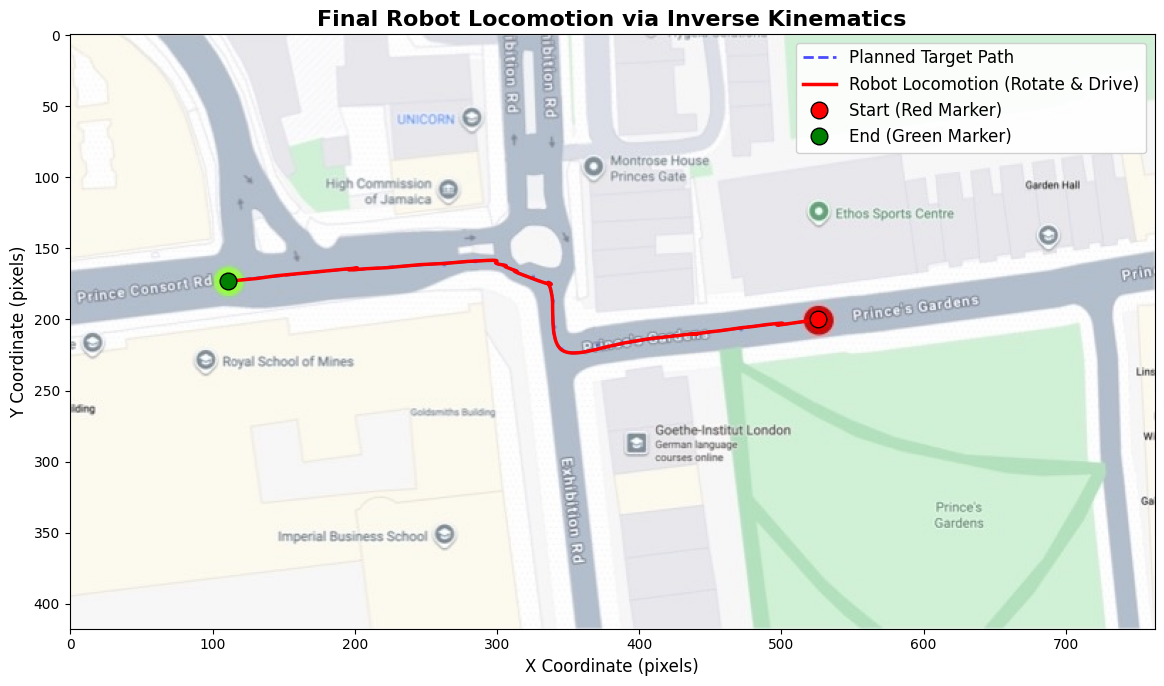

In [130]:
# 2. Initialize the figure (make it large enough for the report)
plt.figure(figsize=(14, 8))
plt.imshow(img)

# 3. Plot the Planned Path (Target)
# smooth_path is your array of pixel coordinates from the Cubic Spline
plt.plot(smooth_path[:, 0], smooth_path[:, 1], 'b--', 
         label='Planned Target Path', linewidth=2, alpha=0.7)

# 4. Plot the Actual Robot Locomotion
# robot_trajectory is the output from the Phase 4 simulation (converted back to pixels)
plt.plot(robot_trajectory[:, 0], robot_trajectory[:, 1], 'r-', 
         label='Robot Locomotion (Rotate & Drive)', linewidth=2.5)

# 5. Highlight Start and End points for clarity
plt.plot(start_pos[0], start_pos[1], 'ro', markersize=12, markeredgecolor='black', label='Start (Red Marker)')
plt.plot(end_pos[0], end_pos[1], 'go', markersize=12, markeredgecolor='black', label='End (Green Marker)')

# 6. Formatting to make it look professional for the report
plt.title('Final Robot Locomotion via Inverse Kinematics', fontsize=16, fontweight='bold')
plt.xlabel('X Coordinate (pixels)', fontsize=12)
plt.ylabel('Y Coordinate (pixels)', fontsize=12)

# Place the legend in a clear spot
plt.legend(loc='upper right', fontsize=12, framealpha=0.9)

# 7. Save the figure in high resolution for your report
plt.savefig('Robot_Locomotion_Result.png', dpi=300, bbox_inches='tight')
plt.show()